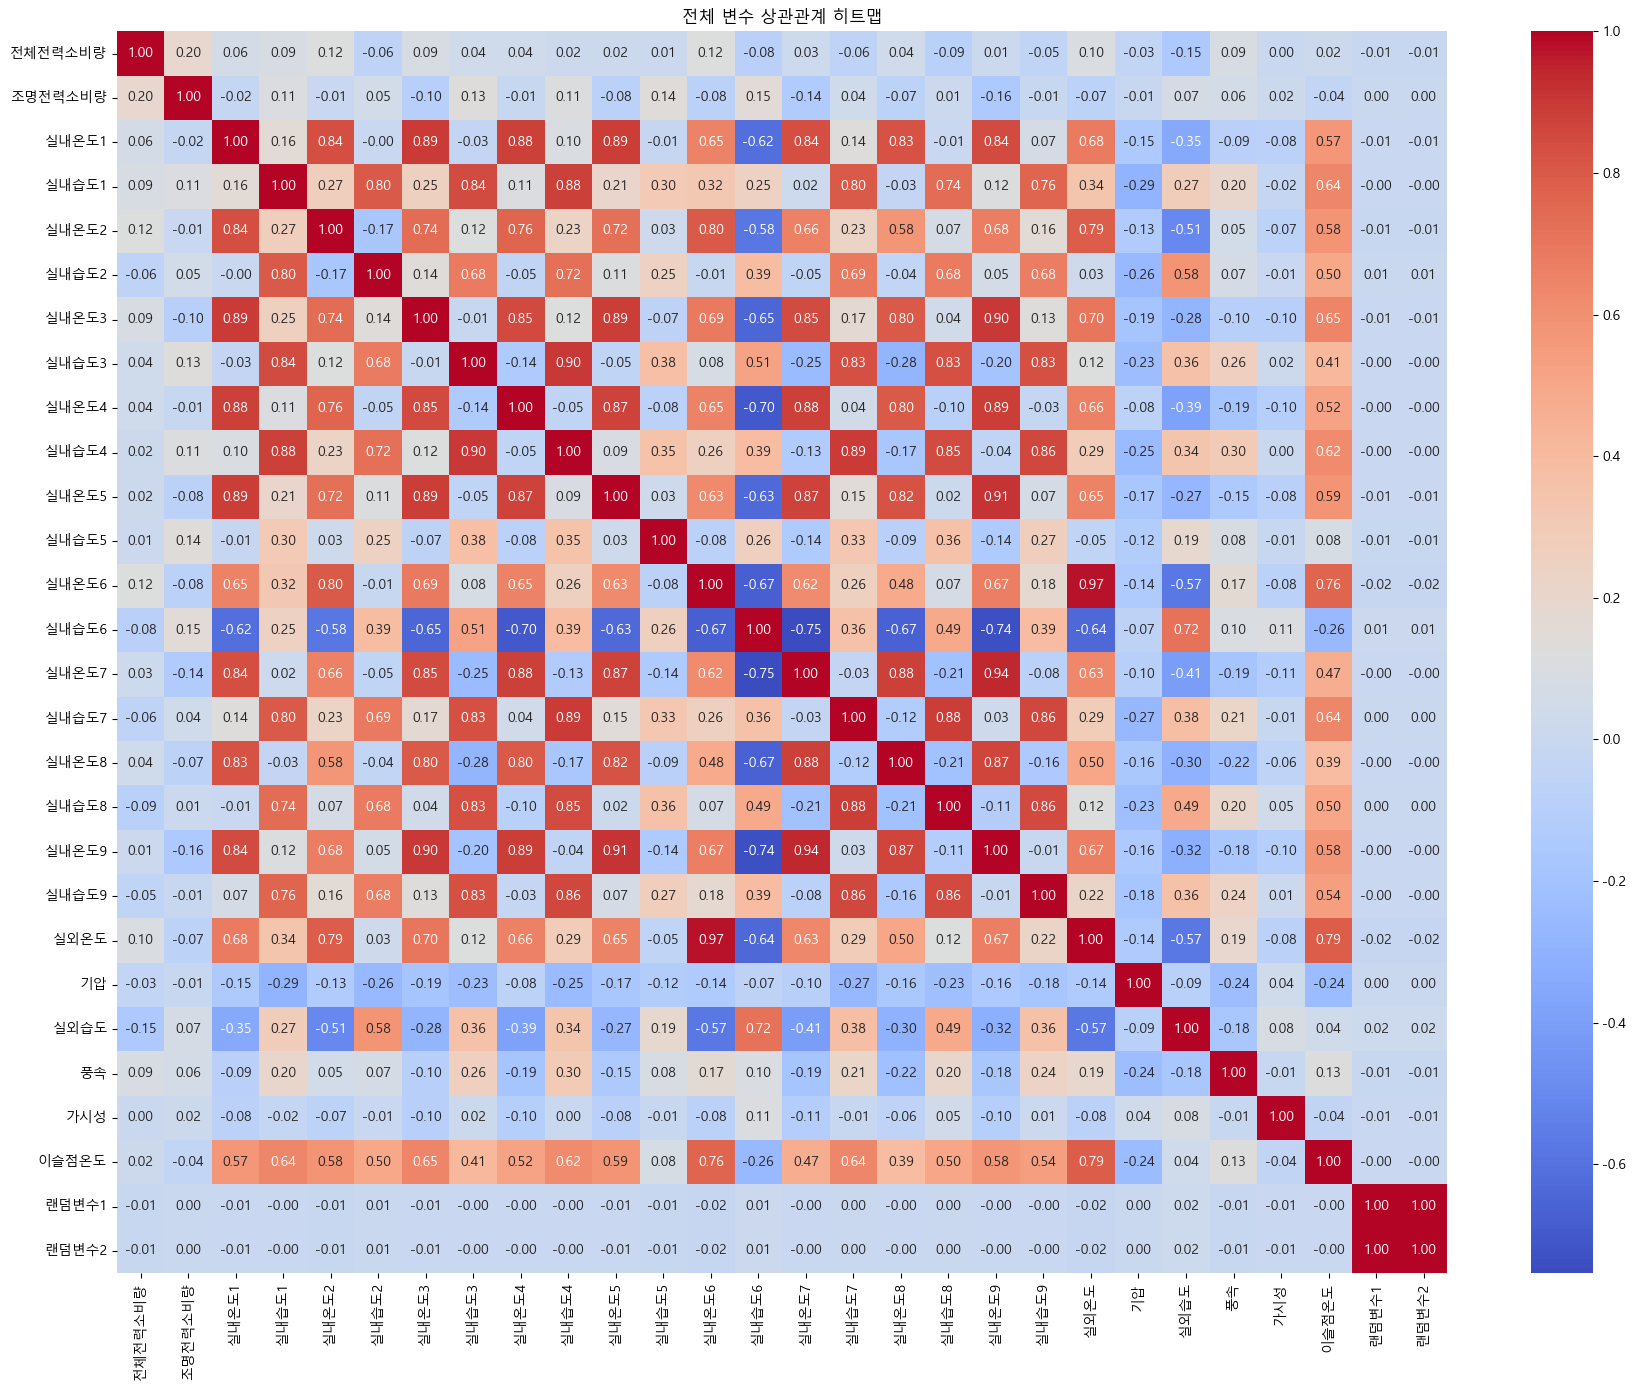

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

# 데이터 불러오기
df = pd.read_csv('./KAG_energydata_complete.csv')

# date 제외 (문자열이라 상관계수 계산 불가)
df_numeric = df.drop(columns=['date'])

# 컬럼명 한글 변환
new_columns = []

for col in df_numeric.columns:
    if col == 'Appliances':
        new_columns.append('전체전력소비량')
    elif col == 'lights':
        new_columns.append('조명전력소비량')
    elif col == 'T_out':
        new_columns.append('실외온도')
    elif col == 'RH_out':
        new_columns.append('실외습도')
    elif col.startswith('T') and col[1:].isdigit():
        new_columns.append(f'실내온도{col[1:]}')
    elif col.startswith('RH_'):
        new_columns.append(f'실내습도{col.split("_")[1]}')
    elif col == 'Windspeed':
        new_columns.append('풍속')
    elif col == 'Visibility':
        new_columns.append('가시성')
    elif col == 'Press_mm_hg':
        new_columns.append('기압')
    elif col == 'Tdewpoint':
        new_columns.append('이슬점온도')
    elif col == 'rv1':
        new_columns.append('랜덤변수1')
    elif col == 'rv2':
        new_columns.append('랜덤변수2')
    else:
        new_columns.append(col)

df_numeric.columns = new_columns

# 상관관계 계산
corr = df_numeric.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('전체 변수 상관관계 히트맵')
plt.tight_layout()
plt.savefig('heatmap_full.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()